**pogrubiony tekst**
##Ćw. 13_2: Q-learning

# Instrukcje Google CoLab

Poniższy kod zapewnia, że Google CoLab uruchamia poprawną wersję TensorFlow.

In [ ]:
try:
    from google.colab import drive
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

Note: using Google CoLab


In [ ]:
# HIDE OUTPUT
if COLAB:
  !pip install gymnasium[accept-rom-license,atari]
  !pip install pyvirtualdisplay
  !sudo apt-get install -y xvfb ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.14).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


# Część 12.2: Wprowadzenie do Q-Learning


Q-Learning to podstawowa technologia, na której opiera się głębokie uczenie ze wzmocnieniem. Zanim zbadamy głębokie uczenie ze wzmocnieniem, konieczne jest zrozumienie Q-Learning. Każdy system Q-Learning składa się z kilku komponentów.

**Agent** - Agent jest bytem istniejącym w środowisku, który podejmuje działania wpływające na stan środowiska, aby otrzymywać nagrody.
**Środowisko** - Środowisko to wszechświat, w którym istnieje agent. Środowisko jest zawsze w określonym stanie, który jest zmieniany przez działania agenta.
**Akcje** - kroki, które agent może wykonać, aby zmienić środowisko
**Krok** - krok ma miejsce, gdy agent wykonuje działanie i potencjalnie zmienia stan środowiska.
* **Epizod** - łańcuch kroków, który ostatecznie kończy się wejściem środowiska w stan końcowy.
* **Epizod** - iteracja szkoleniowa agenta, która zawiera pewną liczbę epizodów.
* **Stan końcowy** - stan, w którym dalsze działania nie mają sensu. Stan końcowy występuje, gdy agent ma jeden, utracony lub środowisko przekracza maksymalną liczbę kroków w wielu środowiskach.

Q-Learning działa poprzez tworzenie tabeli, która sugeruje działanie dla każdego możliwego stanu. Podejście to napotyka na kilka problemów. Po pierwsze, środowisko składa się zwykle z kilku liczb ciągłych, co skutkuje nieskończoną liczbą stanów. Q-Learning obsługuje stany ciągłe poprzez dzielenie tych wartości liczbowych na zakresy.


Q-Learning nie radzi sobie z ciągłymi danymi wejściowymi, takimi jak przyspieszenie samochodu, które może wahać się od zwolnienia do pełnego włączenia. Ponadto, Q-Learning zajmuje się przede wszystkim dyskretnymi działaniami, takimi jak naciskanie joysticka w górę lub w dół. Naukowcy opracowali sprytne sztuczki, aby umożliwić Q-Learning dostosowanie się do ciągłych działań.

Głębokie sieci neuronowe mogą pomóc rozwiązać problemy związane z ciągłymi środowiskami i przestrzeniami akcji. W następnej sekcji dowiemy się więcej o głębokim uczeniu ze wzmocnieniem. Na razie zastosujemy zwykłe uczenie Q-Learning do problemu Mountain Car z OpenAI Gym.


## Opis samochodu górskiego

Pokażemy, w jaki sposób Q-Learning może stworzyć rozwiązanie dla środowiska  Mountain Car. Górski samochód to środowisko, w którym samochód musi wspiąć się na górę. Ponieważ grawitacja jest silniejsza niż silnik samochodu, nie może on po prostu przyspieszyć na stromym zboczu, nawet przy pełnym gazie. Pojazd znajduje się w dolinie i musi nauczyć się wykorzystywać energię potencjalną, wjeżdżając na przeciwległe wzgórze, zanim dotrze do celu na szczycie prawego wzgórza.

Po pierwsze, pomocne może być zwizualizowanie środowiska samochodu górskiego. Poniższy kod przedstawia to środowisko. Kod ten wykorzystuje TF-Agents do wykonania tego renderowania. Zwykle używamy TF-Agents do głębokiego uczenia ze wzmocnieniem, które zobaczymy w następnym module. Jednak na razie TF-Agents jest używany tylko do renderowania środowiska opieki górskiej.

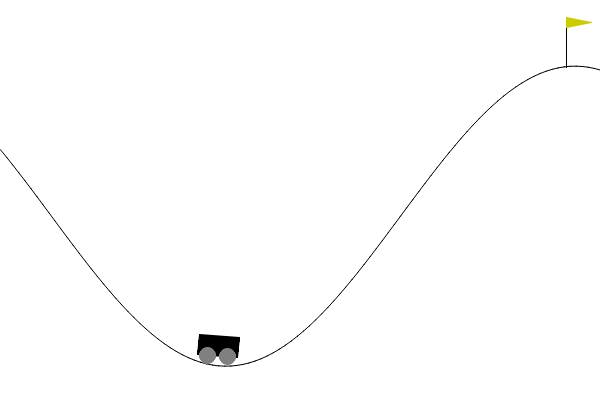

In [ ]:
import gymnasium as gym
from PIL import Image
from IPython.display import display

# Create and initialize the MountainCar environment
env = gym.make('MountainCar-v0', render_mode="rgb_array")
env.reset()

# Render the environment's state to a numpy array
frame = env.render()

# Convert the numpy array to an image and display it
image = Image.fromarray(frame)

# Don't forget to close the environment when you're done!
env.close()

display(image)


Środowisko samochodu górskiego zapewnia następujące dyskretne działania:

* 0 - zastosowanie lewej siły
* 1 - brak siły
* 2 - przyłożenie prawej siły

Środowisko samochodu górskiego składa się z następujących wartości ciągłych:

* state[0] - Position
* state[1] - prędkość

Wózek nie jest wystarczająco silny. Będzie musiał wykorzystać energię potencjalną z góry za nim. Poniższy kod pokazuje agenta, który używa pełnego gazu, aby wspiąć się na wzgórze.

In [ ]:
import gym
import gymnasium as gymnasium
from gymnasium.wrappers import RecordVideo
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display
import numpy as np

# Start virtual display
display = Display(visible=0, size=(1400, 900))
display.start()

# Create Mountain Car environment
env = gymnasium.make('MountainCar-v0', render_mode="rgb_array")
env.metadata['render_fps'] = 30


# Setup the wrapper to record the video
video_callable=lambda episode_id: True
env = RecordVideo(env, video_folder='./videos', episode_trigger=video_callable)
# Reset the environment
env.reset()

# Run the environment until done

truncated = False
i=0
while not truncated:
  i+=1
  action = 2
  state, reward, terminated, truncated , info = env.step(action)
  print(f"Step {i}: State={state}, Reward={reward}, term={terminated}, trunc={truncated}, info={info}")

env.stop_recording()

env.close()

# Display the video
video = io.open(glob.glob('videos/*.mp4')[0], 'r+b').read()
encoded = base64.b64encode(video)
ipythondisplay.display(HTML(data='''
    <video width="640" height="480" controls>
        <source src="data:video/mp4;base64,{0}" type="video/mp4" />
    </video>
'''.format(encoded.decode('ascii'))))


Step 1: State=[-4.2957509e-01  3.0634337e-04], Reward=-1.0, term=False, trunc=False, info={}
Step 2: State=[-0.42896459  0.00061048], Reward=-1.0, term=False, trunc=False, info={}
Step 3: State=[-0.4280544   0.00091022], Reward=-1.0, term=False, trunc=False, info={}
Step 4: State=[-0.42685097  0.00120341], Reward=-1.0, term=False, trunc=False, info={}
Step 5: State=[-0.42536303  0.00148794], Reward=-1.0, term=False, trunc=False, info={}
Step 6: State=[-0.42360124  0.0017618 ], Reward=-1.0, term=False, trunc=False, info={}
Step 7: State=[-0.42157823  0.00202301], Reward=-1.0, term=False, trunc=False, info={}
Step 8: State=[-0.41930848  0.00226975], Reward=-1.0, term=False, trunc=False, info={}
Step 9: State=[-0.4168082   0.00250027], Reward=-1.0, term=False, trunc=False, info={}
Step 10: State=[-0.41409522  0.00271297], Reward=-1.0, term=False, trunc=False, info={}
Step 11: State=[-0.41118884  0.00290639], Reward=-1.0, term=False, trunc=False, info={}
Step 12: State=[-0.40810964  0.0030

/usr/local/lib/python3.11/dist-packages/moviepy/config_defaults.py:1: DeprecationWarning: invalid escape sequence '\P'
  """



## Zaprogramowany samochód

Teraz przyjrzymy się samochodowi, który zaprogramowałem ręcznie. Ten samochód jest prosty, ale rozwiązuje problem. Zaprogramowany samochód zawsze wywiera siłę w tym czy innym kierunku. Nie łamie się. Niezależnie od kierunku, w którym pojazd aktualnie się porusza, agent wykorzystuje moc w tym kierunku. Dlatego samochód zaczyna wspinać się na wzgórze, jest przeciążony i skręca do tyłu. Jednak gdy zacznie się toczyć do tyłu, siła zostanie natychmiast przyłożona w nowym kierunku.

Poniższy kod implementuje ten zaprogramowany samochód.

In [ ]:
import gym
import gymnasium as gymnasium
from gymnasium.wrappers import RecordVideo
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display
import numpy as np
import os # Import os module to check file creation time

# Start virtual display
display = Display(visible=0, size=(1400, 900))
display.start()

# Create Mountain Car environment
env = gymnasium.make('MountainCar-v0', render_mode="rgb_array")
env.metadata['render_fps'] = 30

# Setup the wrapper to record the video
# Apply the wrapper BEFORE the first env.reset() call
video_callable=lambda episode_id: True
# Record only the first episode for demonstration purposes
env = RecordVideo(env, video_folder='./videos', episode_trigger=video_callable, disable_logger=True)

# Reset the environment AFTER applying the wrapper
# This also starts the recording for the first episode
state, info = env.reset()

# Run the environment until done or maximum steps reached
terminated = False
truncated = False
i=0
action = 2
MAX_STEPS = 500 # Add a maximum number of steps to prevent infinite loops

# Continue as long as the episode is not terminated or truncated, and we haven't exceeded max steps
while not terminated and not truncated and i < MAX_STEPS:
  i+=1
  state, reward, terminated, truncated , info = env.step(action)
  # print(f"Step {i}: State={state}, Reward={reward}, term={terminated}, trunc={truncated}, info={info}") # Uncomment for debugging
  if state[1] > 0:
    action = 2
  else:
    action = 0

# It's important to call close on the wrapped environment, which handles the underlying env.
env.close()

# stop_recording is automatically called by env.close() when using RecordVideo wrapper
# However, if the loop exits immediately and no recording started, stop_recording() will fail.
# A better approach with RecordVideo is to let close() handle the recording stop.
# If you need more control, you can manually call start_recording() and stop_recording()
# but this requires careful handling of the recording state.

# For robustness, ensure the video directory exists before trying to list files
if not os.path.exists('./videos'):
    os.makedirs('./videos')

# Display the video
# Check if any video file was recorded
list_of_files = glob.glob('videos/*.mp4')
if list_of_files:
    # Get the most recent video file
    latest_file = max(list_of_files, key=os.path.getctime)
    video = io.open(latest_file, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''
        <video width="640" height="480" controls>
            <source src="data:video/mp4;base64,{0}" type="video/mp4" />
        </video>
    '''.format(encoded.decode('ascii'))))
else:
    print("No video file was recorded.")

/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


##Q-Learning

Uczenie się przez wzmacnianie
Q-Learning to system nagród, które algorytm przyznaje agentowi za pomyślne przeniesienie środowiska do stanu uznawanego za udany. Nagrody te to wartości Q, od których ten algorytm wziął swoją nazwę. Końcowym wynikiem algorytmu Q-Learning jest tabela wartości Q, które wskazują wartość nagrody za każdą akcję, którą agent może wykonać, biorąc pod uwagę każdy możliwy stan środowiska. Agent musi umieścić ciągłe wartości stanu w ustalonej skończonej liczbie kolumn.

Uczenie się następuje, gdy algorytm uruchamia agenta i środowisko przez epizody i aktualizuje wartości Q na podstawie nagród otrzymanych za podjęte działania; Rysunek 12.REINF zapewnia ogólny przegląd tego wzmocnienia lub pętli Q-Learning.

**Figure 12.REINF:Reinforcement/Q Learning**
![Reinforcement Learning](https://raw.githubusercontent.com/jeffheaton/t81_558_deep_learning/master/images/reinforcement.png "Reinforcement Learning")

Wartości Q mogą dyktować działanie poprzez wybranie kolumny działania o najwyższej wartości Q dla bieżącego stanu środowiska. Wybór między wyborem losowego działania a działaniem sterowanym wartością Q jest regulowany przez parametr epsilon ($\epsilon$), prawdopodobieństwo losowego działania.

Za każdym razem, gdy przechodzi przez pętlę treningową, algorytm treningowy aktualizuje wartości Q zgodnie z następującym równaniem.

$Q^{new}(s_{t},a_{t}) \leftarrow \underbrace{Q(s_{t},a_{t})}_{\text{old value}} + \underbrace{\alpha}_{\text{learning rate}} \cdot  \overbrace{\bigg( \underbrace{\underbrace{r_{t}}_{\text{reward}} + \underbrace{\gamma}_{\text{discount factor}} \cdot \underbrace{\max_{a}Q(s_{t+1}, a)}_{\text{estimate of optimal future value}}}_{\text{new value (temporal difference target)}} - \underbrace{Q(s_{t},a_{t})}_{\text{old value}} \bigg) }^{\text{temporal difference}}$

Parametry, które sa w równaniu:
* alpha ($\alpha$) - Szybkość uczenia się, czyli w jakim stopniu bieżący krok powinien powodować aktualizację wartości Q.
* lambda ($\lambda$) - Współczynnik dyskontowy to procent przyszłej nagrody, którą algorytm powinien uwzględnić w tej aktualizacji.

To równanie modyfikuje kilka wartości:

* $Q(s_t,a_t)$ - Tablica Q-table.  Jaką nagrodę najprawdopodobniej otrzymałby agent za wykonanie każdej akcji w każdej kombinacji stanów?
* $s_t$ - Bieżąca nagroda.
* $r_t$ - ostatnia otrzymana nagroda.
* $a_t$ - Akcja, która wykona agent.

Równanie działa poprzez obliczenie delty (różnicy czasowej), którą równanie powinno zastosować do starego stanu. Ta szybkość uczenia się ($\alpha$) skaluje tę deltę. Szybkość uczenia się wynosząca 1,0 w pełni wdrożyłaby różnicę czasową w wartościach Q w każdej iteracji i prawdopodobnie byłaby bardzo chaotyczna.

Różnica czasowa składa się z dwóch części: nowej i starej wartości. Nowa wartość jest odejmowana od starej wartości, aby zapewnić deltę; pełną kwotę, o którą zmienilibyśmy wartość Q, gdyby szybkość uczenia się nie skalowała tej wartości. Nowa wartość jest sumą nagrody otrzymanej z ostatniej akcji i maksymalnych wartości Q ze stanu wynikowego, gdy klient podejmuje tę akcję. Dodanie maksymalnej wartości Q akcji dla nowego stanu jest niezbędne, ponieważ szacuje optymalne przyszłe wartości z kontynuowania tej akcji.

## Q-Learning Car

Teraz użyjemy Q-Learning, aby wyprodukować samochód, który uczy się jeździć sam. Uważaj, Tesla! Zaczynamy od zdefiniowania dwóch podstawowych funkcji.

In [ ]:
import gymnasium
import numpy as np

# This function converts the floating point state values into
# discrete values. This is often called binning.  We divide
# the range that the state values might occupy and assign
# each region to a bucket.
def calc_discrete_state(state):
    discrete_state = (state - env.observation_space.low)/buckets
    return tuple(discrete_state.astype(int))

# Run one game.  The q_table to use is provided.  We also
# provide a flag to indicate if the game should be
# rendered/animated.  Finally, we also provide
# a flag to indicate if the q_table should be updated.
def run_game(q_table, render, should_update):
    done = False
    discrete_state = calc_discrete_state(env.reset()[0])
    success = False

    while not done:
        # Exploit or explore
        if np.random.random() > epsilon:
            # Exploit - use q-table to take current best action
            # (and probably refine)
            action = np.argmax(q_table[discrete_state])
        else:
            # Explore - t
            action = np.random.randint(0, env.action_space.n)

        # Run simulation step
        new_state, reward, done, _, _ = env.step(action)

        # Convert continuous state to discrete
        new_state_disc = calc_discrete_state(new_state)

        # Have we reached the goal position (have we won?)?
        if new_state[0] >= env.unwrapped.goal_position:
            success = True

        # Update q-table
        if should_update:
            max_future_q = np.max(q_table[new_state_disc])
            current_q = q_table[discrete_state + (action,)]
            new_q = (1 - LEARNING_RATE) * current_q + LEARNING_RATE * \
                (reward + DISCOUNT * max_future_q)
            q_table[discrete_state + (action,)] = new_q

        discrete_state = new_state_disc

        if render:
            env.render()

    return success


Kilka hiperparametrów jest bardzo ważnych dla Q-Learning. Parametry te prawdopodobnie będą wymagały dostosowania, gdy zastosujesz Q-Learning do innych problemów. Z tego powodu kluczowe jest zrozumienie roli każdego parametru.

* **LEARNING_RATE** Szybkość, z jaką poprzednie wartości Q są aktualizowane na podstawie nowych odcinków uruchomionych podczas treningu.
* **DISCRETE_GRID_SIZE** Ilość istotności, aby uzyskać szacunki przyszłych nagród po dodaniu do nagrody za aktualnie podjętą akcję. Wartość 0,95 oznaczałaby 5% zniżki na przyszłe szacunki nagród.
* **EPISODES** Liczba odcinków do trenowania. Zwiększ tę wartość w przypadku bardziej złożonych problemów; jednak czas treningu również się wydłuża.
* **SHOW_EVERY** Ile odcinków należy pozostawić, aby upłynęła aktualizacja.
* **DISCRETE_GRID_SIZE** Ile przedziałów należy użyć podczas konwersji każdej ciągłej zmiennej stanu. Na przykład [10, 10] oznacza, że ​​algorytm powinien używać dziesięciu przedziałów dla pierwszej i drugiej zmiennej stanu.
* **START_EPSILON_DECAYING** Epsilon to prawdopodobieństwo, że agent wybierze losową akcję spośród sugerowanych przez Q-Table. Ta wartość określa początkowe prawdopodobieństwo losowości.
* **END_EPSILON_DECAYING** Ile odcinków powinno upłynąć, zanim epsilon osiągnie zero i nie będą dozwolone żadne losowe akcje. Na przykład EPISODES//10 oznacza, że ​​tylko pierwsza 1/10 odcinków może mieć losowe akcje.

In [ ]:
LEARNING_RATE = 0.1
DISCOUNT = 0.95
EPISODES = 500
SHOW_EVERY = 100

DISCRETE_GRID_SIZE = [10, 10]
START_EPSILON_DECAYING = 0.5
END_EPSILON_DECAYING = EPISODES//10


Teraz możemy utworzyć środowisko. Jeśli uruchamiamy w Google COLAB, opakowujemy środowisko, aby było wyświetlane w przeglądarce internetowej. Następnie tworzymy oddzielne kontenery dla stanu i budujemy Q-table.

In [ ]:
env = gymnasium.make("MountainCar-v0")

epsilon = 1
epsilon_change = epsilon/(END_EPSILON_DECAYING - START_EPSILON_DECAYING)
buckets = (env.observation_space.high - env.observation_space.low) \
    / DISCRETE_GRID_SIZE
q_table = np.random.uniform(low=-3, high=0, size=(DISCRETE_GRID_SIZE
                                                  + [env.action_space.n]))
success = False


In [ ]:
episode = 0
success_count = 0

# Loop through the required number of episodes
while episode < EPISODES:
    episode += 1
    done = False

    # Run the game.  If we are local, display render animation
    # at SHOW_EVERY intervals.
    if episode % SHOW_EVERY == 0:
        print(f"Current episode: {episode}, success: {success_count}" +
              f" {(float(success_count)/SHOW_EVERY)}")
        success = run_game(q_table, True, False)
        success_count = 0
    else:
        success = run_game(q_table, False, True)

    # Count successes
    if success:
        success_count += 1

    # Move epsilon towards its ending value, if it still needs to move
    if END_EPSILON_DECAYING >= episode >= START_EPSILON_DECAYING:
        epsilon = max(0, epsilon - epsilon_change)

print(success)


Current episode: 100, success: 99 0.99


/usr/local/lib/python3.11/dist-packages/gymnasium/envs/classic_control/mountain_car.py:179: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("MountainCar-v0", render_mode="rgb_array")
  gym.logger.warn(


Current episode: 200, success: 100 1.0
Current episode: 300, success: 100 1.0
Current episode: 400, success: 100 1.0
Current episode: 500, success: 100 1.0
True


Jak widać, liczba udanych epizodów zazwyczaj wzrasta w miarę postępu treningu. Nie zaleca się zatrzymywania się, gdy po raz pierwszy zaobserwujemy 100% sukcesu w 1000 epizodach. W większości gier występuje losowość, więc mało prawdopodobne jest, aby agent zachował 100% wskaźnik sukcesu przy nowym przebiegu. Zatrzymanie treningu może być bezpieczne, gdy zaobserwujesz, że agent uzyskał 100% w kilku odstępach aktualizacji.

## Uruchamianie i obserwowanie agenta

Teraz, gdy algorytm wytrenował agenta, możemy obserwować agenta w akcji. Możesz użyć następującego kodu, aby zobaczyć agenta w akcji.

In [ ]:
# HIDE OUTPUT

# Setup the wrapper to record the video
env = gymnasium.make("MountainCar-v0", render_mode="rgb_array")
video_callable=lambda episode_id: True
env = RecordVideo(env, video_folder='./videos', episode_trigger=video_callable)

run_game(q_table, True, False)

# Display the video
video = io.open(glob.glob('videos/*.mp4')[0], 'r+b').read()
encoded = base64.b64encode(video)
ipythondisplay.display(HTML(data='''
    <video width="640" height="480" controls>
        <source src="data:video/mp4;base64,{0}" type="video/mp4" />
    </video>
'''.format(encoded.decode('ascii'))))


## Inspekcja tabeli Q

Możemy również wyświetlić tabelę Q. Poniższy kod pokazuje działanie agenta dla każdego stanu środowiska. Jako wagi sieci neuronowej, ta tabela nie jest prosta do zinterpretowania. Niektóre wzorce pojawiają się w tym kierunku, jak widać po obliczeniu średnich wierszy i kolumn. Działania wydają się spójne zarówno w górnej, jak i dolnej połowie prędkości i pozycji.

In [ ]:
import pandas as pd

df = pd.DataFrame(q_table.argmax(axis=2))

df.columns = [f'v-{x}' for x in range(DISCRETE_GRID_SIZE[0])]
df.index = [f'p-{x}' for x in range(DISCRETE_GRID_SIZE[1])]
df


,v-0,v-1,v-2,v-3,v-4,v-5,v-6,v-7,v-8,v-9
p-0,2,2,2,2,2,2,2,2,1,1
p-1,2,0,2,2,2,2,2,2,0,1
p-2,0,0,0,0,2,1,2,2,1,0
p-3,2,0,0,0,0,1,2,2,2,0
p-4,0,0,0,1,1,0,1,2,2,2
p-5,0,0,1,0,1,0,0,2,1,2
p-6,1,0,0,0,0,0,2,1,2,1
p-7,2,1,2,0,0,1,2,2,2,2
p-8,0,0,0,1,0,0,2,2,2,2
p-9,2,2,2,1,0,0,1,1,0,2


In [ ]:
df.mean(axis=0)

,0
v-0,1.1
v-1,0.5
v-2,0.9
v-3,0.7
v-4,0.8
v-5,0.7
v-6,1.6
v-7,1.8
v-8,1.3
v-9,1.3


In [ ]:
df.mean(axis=1)

,0
p-0,1.8
p-1,1.5
p-2,0.8
p-3,0.9
p-4,0.9
p-5,0.7
p-6,0.7
p-7,1.4
p-8,0.9
p-9,1.1
